<a href="https://colab.research.google.com/github/yassminechiha-bot/KPI-Prediction-LSTM/blob/main/lstmhypertuningfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install  keras==2.12.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 9.9 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.15.0
    Uninstalling keras-2.15.0:
      Successfully uninstalled keras-2.15.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.15.0 requires keras<2.16,>=2.15.0, but you have keras 2.12.0 which is incompatible.


In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from keras.optimizers import Adam
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_val_score, KFold
import keras
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split  # Ajout de l'import pour train_test_split
from keras.models import Sequential
from keras.layers import LSTM, Dense
from google.colab import drive
# Création de la fonction pour construire le modèle
# Création de la fonction pour construire le modèle
# Création de la fonction pour construire le modèle
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.model_selection import GridSearchCV
import keras
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
import keras
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# Lecture du fichier CSV
df = pd.read_csv('/content/drive/MyDrive/factData.csv')

# Conversion de la colonne 'DATE' en format datetime
df['DATE'] = pd.to_datetime(df['DATE']).dt.date

# Réindexation du DataFrame avec la colonne 'DATE'
df = df.set_index('DATE', drop=True)
print(df)

# Vérification des valeurs manquantes dans chaque colonne
df.isnull().sum()

# Suppression des lignes avec des valeurs manquantes dans la colonne 'CA'
df.dropna(subset=['CA'], inplace=True)

# Grouper les données par date et sommer les valeurs des autres colonnes
df = df.groupby('DATE').sum().reset_index()
print(df)

                   CA
DATE                 
2022-11-08   3279.074
2022-04-08    175.001
2022-06-01  23187.689
2023-01-09   7313.400
2022-10-01    113.400
...               ...
2023-05-04   9530.000
2023-06-14  13377.000
2023-03-30  13377.000
2023-04-03    255.601
2023-04-03    418.499

[354129 rows x 1 columns]
           DATE           CA
0    2022-01-01  2993481.234
1    2022-01-02  1677974.518
2    2022-01-03  7877666.397
3    2022-01-04  7900466.474
4    2022-01-05  8904312.305
..          ...          ...
723  2023-12-27  7742734.660
724  2023-12-28  8461590.206
725  2023-12-29  8363723.213
726  2023-12-30  9310818.502
727  2023-12-31   101740.376

[728 rows x 2 columns]


In [ ]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)


In [ ]:


# Normalisation des données
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df['CA'].values.reshape(-1, 1))

# Split des données en ensembles d'entraînement et de test (80% train, 20% test)
train_size = int(len(df_scaled) * 0.8)
train_data, test_data = df_scaled[:train_size], df_scaled[train_size:]

# Création des données d'entrée et de sortie pour l'entraînement et le test
time_step = 7
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

print(X_train.shape)
print(X_test.shape)

# Reshape des données pour LSTM (samples, time steps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


(574, 7)
(138, 7)


In [ ]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from keras.optimizers import Adam
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM


In [ ]:

# Fonction pour construire le modèle LSTM
def build_lstm_model(n_neurons, activation, learning_rate):
    model = Sequential()
    model.add(LSTM(n_neurons, activation=activation, input_shape=(7, 1)))
    model.add(Dense(1))
    optimizer = Adam(learning_rate=learning_rate)  # Instantiate Adam optimizer
    model.compile(optimizer=optimizer, loss='mse')
    return model

# Définir la grille de paramètres pour GridSearchCV
param_grid = {
    'n_neurons': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'activation': ['relu'],
    'learning_rate': [0.001, 0.01, 0.1, 1]
}

# Initialiser TimeSeriesSplit avec le nombre de splits désiré
tscv = TimeSeriesSplit(n_splits=3)
keras_reg = KerasRegressor(build_fn=build_lstm_model)

# Créer l'objet GridSearchCV avec l'instance KerasRegressor et TimeSeriesSplit
grid_search = GridSearchCV(estimator=keras_reg, param_grid=param_grid, cv=tscv)

# Adapter la recherche sur grille à vos données
grid_search.fit(X_train, y_train, epochs=300, verbose=1,batch_size=32)


<ipython-input-8-b20c0f39e9f2>:19: DeprecationWarning: KerasRegressor is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  keras_reg = KerasRegressor(build_fn=build_lstm_model)


Streaming output truncated to the last 5000 lines.
Epoch 206/300
5/5 [==============================] - 0s 12ms/step - loss: 120795.2656
Epoch 207/300
5/5 [==============================] - 0s 10ms/step - loss: 120794.8281
Epoch 208/300
5/5 [==============================] - 0s 11ms/step - loss: 120794.0938
Epoch 209/300
5/5 [==============================] - 0s 10ms/step - loss: 120793.4922
Epoch 210/300
5/5 [==============================] - 0s 10ms/step - loss: 120792.9375
Epoch 211/300
5/5 [==============================] - 0s 10ms/step - loss: 120792.3594
Epoch 212/300
5/5 [==============================] - 0s 10ms/step - loss: 120791.6719
Epoch 213/300
5/5 [==============================] - 0s 10ms/step - loss: 120791.0625
Epoch 214/300
5/5 [==============================] - 0s 10ms/step - loss: 120790.4375
Epoch 215/300
5/5 [==============================] - 0s 10ms/step - loss: 120790.1094
Epoch 216/300
5/5 [==============================] - 0s 10ms/step - loss: 120789.3516
Epo

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:952: UserWarning: One or more of the test scores are non-finite: [-2.98124750e-02 -2.04007256e-02 -2.23243764e-02 -2.19464625e-02
 -2.20912381e-02 -1.97783566e-02 -1.94482505e-02 -2.15595750e-02
 -2.13638820e-02 -1.85636630e-02 -1.99503855e-02 -1.93991403e-02
 -2.30285951e-02 -2.11987502e-02 -2.17982441e-02 -2.18315677e-02
 -2.25906515e-02 -2.24444720e-02 -2.20632755e-02 -2.95450849e-02
 -5.27781546e-02 -3.12516062e-02 -3.06478556e-02 -3.35234969e-02
 -3.43242893e-02 -3.26869708e-02 -3.59582026e-02 -2.10662723e-02
 -2.34923962e-02 -2.14813820e-02 -5.17008518e+00 -5.32963896e+02
 -1.14050951e+02 -3.31009713e+03 -2.17925184e+04 -7.64221133e+02
             nan             nan -2.73780725e+09             nan]
  warnings.warn(


Epoch 1/300
18/18 [==============================] - 2s 11ms/step - loss: 0.1983
Epoch 2/300
18/18 [==============================] - 0s 10ms/step - loss: 0.0543
Epoch 3/300
18/18 [==============================] - 0s 10ms/step - loss: 0.0498
Epoch 4/300
18/18 [==============================] - 0s 12ms/step - loss: 0.0491
Epoch 5/300
18/18 [==============================] - 0s 10ms/step - loss: 0.0482
Epoch 6/300
18/18 [==============================] - 0s 10ms/step - loss: 0.0473
Epoch 7/300
18/18 [==============================] - 0s 10ms/step - loss: 0.0462
Epoch 8/300
18/18 [==============================] - 0s 11ms/step - loss: 0.0444
Epoch 9/300
18/18 [==============================] - 0s 13ms/step - loss: 0.0435
Epoch 10/300
18/18 [==============================] - 0s 11ms/step - loss: 0.0412
Epoch 11/300
18/18 [==============================] - 0s 11ms/step - loss: 0.0395
Epoch 12/300
18/18 [==============================] - 0s 11ms/step - loss: 0.0374
Epoch 13/300
18/18 [=====

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=<keras.wrappers.scikit_learn.KerasRegressor object at 0x7f3a70d1ec80>,
             param_grid={'activation': ['relu'],
                         'learning_rate': [0.001, 0.01, 0.1, 1],
                         'n_neurons': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                       100]})

In [ ]:
# Obtenir les meilleurs paramètres
best_params_grid = grid_search.best_params_

print("Best Parameters (Grid Search):", best_params_grid)

# Récupérer le meilleur modèle de la recherche sur grille
best_model_grid = grid_search.best_estimator_.model

Best Parameters (Grid Search): {'activation': 'relu', 'learning_rate': 0.001, 'n_neurons': 100}


In [ ]:

# Faire des prédictions sur les ensembles d'entraînement et de test
train_predictions = best_model_grid.predict(X_train)
test_predictions = best_model_grid.predict(X_test)

# Inverser la normalisation des prédictions et des vraies valeurs pour les ensembles de test
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
test_predictions_inverse = scaler.inverse_transform(test_predictions.reshape(-1, 1)).flatten()


5/5 [==============================] - 0s 4ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error


In [ ]:
mse = mean_squared_error(y_test_inverse, test_predictions_inverse)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inverse, test_predictions_inverse)

metrics_df = pd.DataFrame({
    'Modèle': 'LSTM',
    'RMSE': [rmse],
    'MAE': [mae]
})

print(metrics_df)

  Modèle           RMSE            MAE
0   LSTM  793501.450908  584675.227525


In [ ]:
# Création d'un DataFrame pour les données originales
original_df = pd.DataFrame({
    'Date': df.index,
    'Original': scaler.inverse_transform(df_scaled).flatten()
})
original_df.set_index('Date', inplace=True)

# Inverser la normalisation des prédictions et des vraies valeurs
train_predictions_inverse = scaler.inverse_transform(train_predictions)
test_predictions_inverse = scaler.inverse_transform(test_predictions)
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Créer un DataFrame pour les données d'entraînement
train_df = pd.DataFrame({
    'Date': original_df.index[time_step:time_step+len(train_predictions)],
    'Train': train_predictions_inverse.flatten()
})
train_df.set_index('Date', inplace=True)

# Créer un DataFrame pour les données de test
test_df = pd.DataFrame({
    'Date': original_df.index[time_step+len(train_predictions)+time_step:time_step+len(train_predictions)+time_step+len(test_predictions)],
    'Test': test_predictions_inverse.flatten()
})
test_df.set_index('Date', inplace=True)

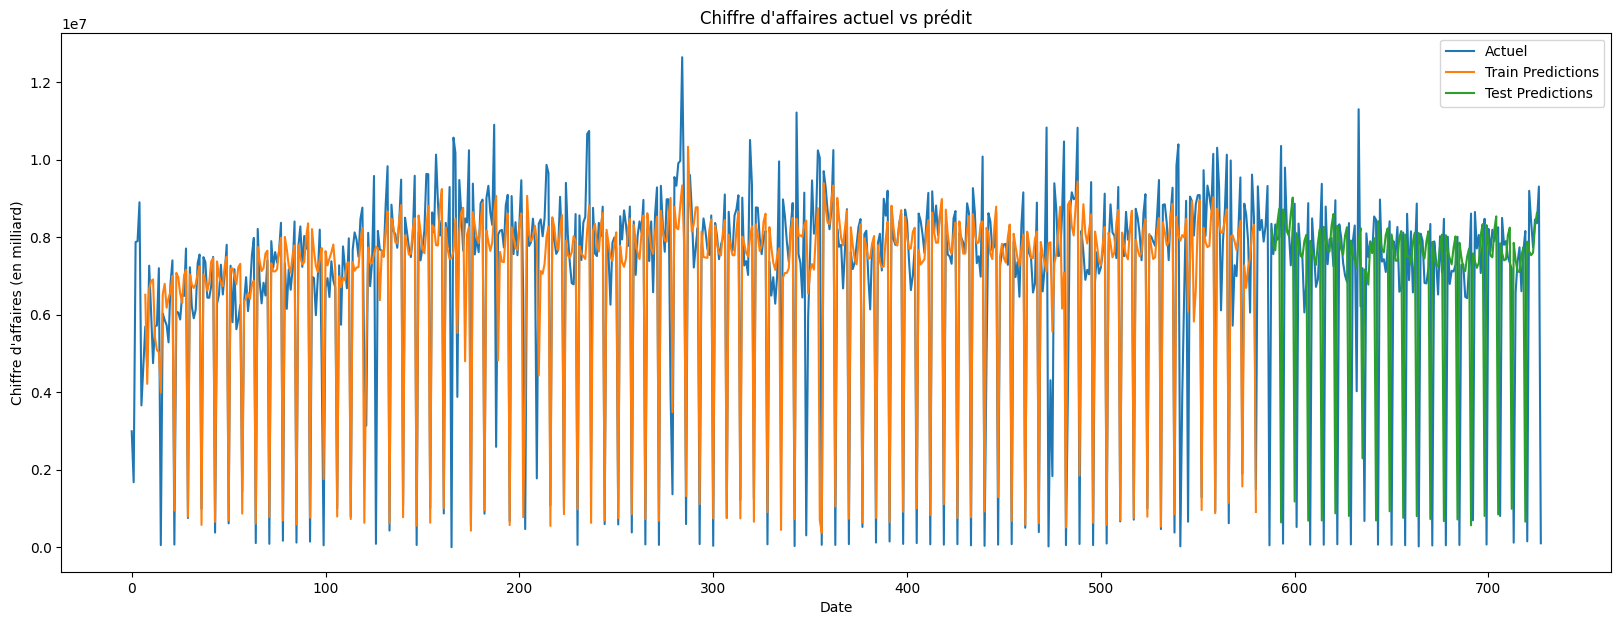

In [ ]:
# Afficher les données originales, d'entraînement et de test sur un graphe
plt.figure(figsize=(20, 7))
plt.plot(original_df.index, original_df['Original'], label='Actuel')
plt.plot(train_df.index, train_df['Train'], label='Train Predictions')
plt.plot(test_df.index, test_df['Test'], label='Test Predictions')
plt.legend()
plt.title('Chiffre d\'affaires actuel vs prédit')
plt.xlabel('Date')
plt.ylabel('Chiffre d\'affaires (en milliard)')
plt.show()


Text(0, 0.5, "Chiffre d'affaires (en milliard)")

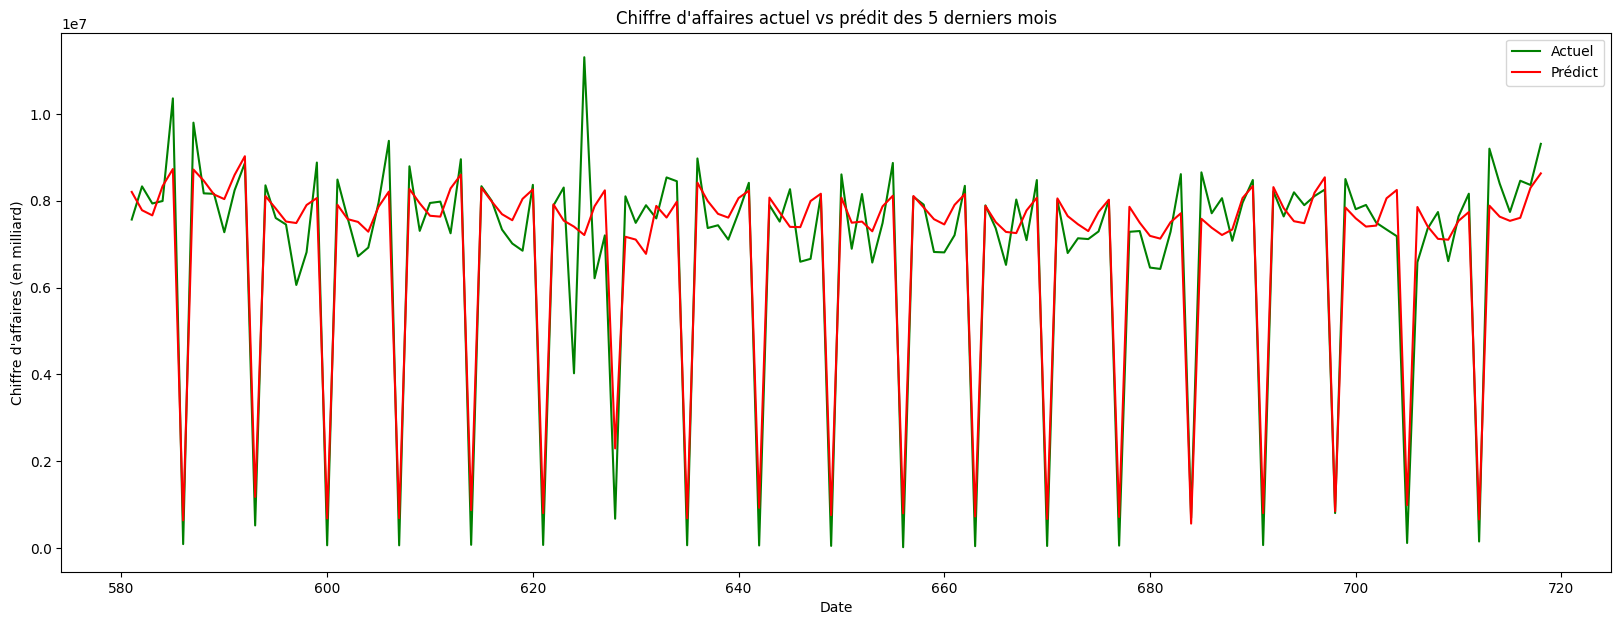

In [ ]:
plt.figure(figsize=(20, 7))
plt.plot(original_df.index[len(train_predictions)+time_step:len(train_predictions)+time_step+len(test_predictions)], y_test_inverse, label='Actuel', color='green')
plt.plot(original_df.index[len(train_predictions)+time_step:len(train_predictions)+time_step+len(test_predictions)], test_predictions_inverse, label='Prédict', color='red')
plt.legend()
plt.title('Chiffre d\'affaires actuel vs prédit des 5 derniers mois')
plt.xlabel('Date')
plt.ylabel('Chiffre d\'affaires (en milliard)')


In [ ]:


test_rmse_arima = np.sqrt(mean_squared_error(test, test_predictions_arima))

test_rmse_sarima = np.sqrt(mean_squared_error(test, test_predictions_sarima))

rmse_lstm = np.sqrt(mean_squared_error(y_test_inverse, test_predictions_lstm))

metrics_df = pd.DataFrame({
    'Modèle': ['ARIMA', 'SARIMA', 'LSTM'],
    'RMSE': [test_rmse_arima, test_rmse_sarima, rmse_lstm]
})

print(metrics_df)


,Modèle,RMSE
0,ARIMA,2 041 919
1,SARIMA,2 955 660
2,LSTM,793501.45


In [ ]:
# Initialiser les données pour la prédiction de l'année 2024
initial_data = X_test[-1]

# Préparer les données pour la prédiction de l'année 2024
predictions_2024 = []
for i in range(366):
    # Prédire le chiffre d'affaires pour le jour suivant
    prediction = best_model_grid.predict(initial_data.reshape(1, n_input, 1))[0][0]
    predictions_2024.append(prediction)

    # Mettre à jour les données d'entrée pour inclure la prédiction récente
    initial_data = np.roll(initial_data, -1)
    initial_data[-1] = prediction

1/1 [==============================] - 0s 35ms/step


In [ ]:
# Ajuster la longueur des prédictions pour correspondre à la longueur de l'index des dates
predictions_2024 = predictions_2024[:len(pd.date_range(start='2024-01-01', end='2024-12-31'))]

# Inverser la normalisation des prédictions
predictions_2024_inverse = scaler.inverse_transform(np.array(predictions_2024).reshape(-1, 1)).flatten()

# Créer un DataFrame pour les prédictions de l'année 2024
predictions_2024_df = pd.DataFrame({
    'Date': pd.date_range(start='2024-01-01', end='2024-12-31'),
    'Predictions': predictions_2024_inverse
})
predictions_2024_df.set_index('Date', inplace=True)

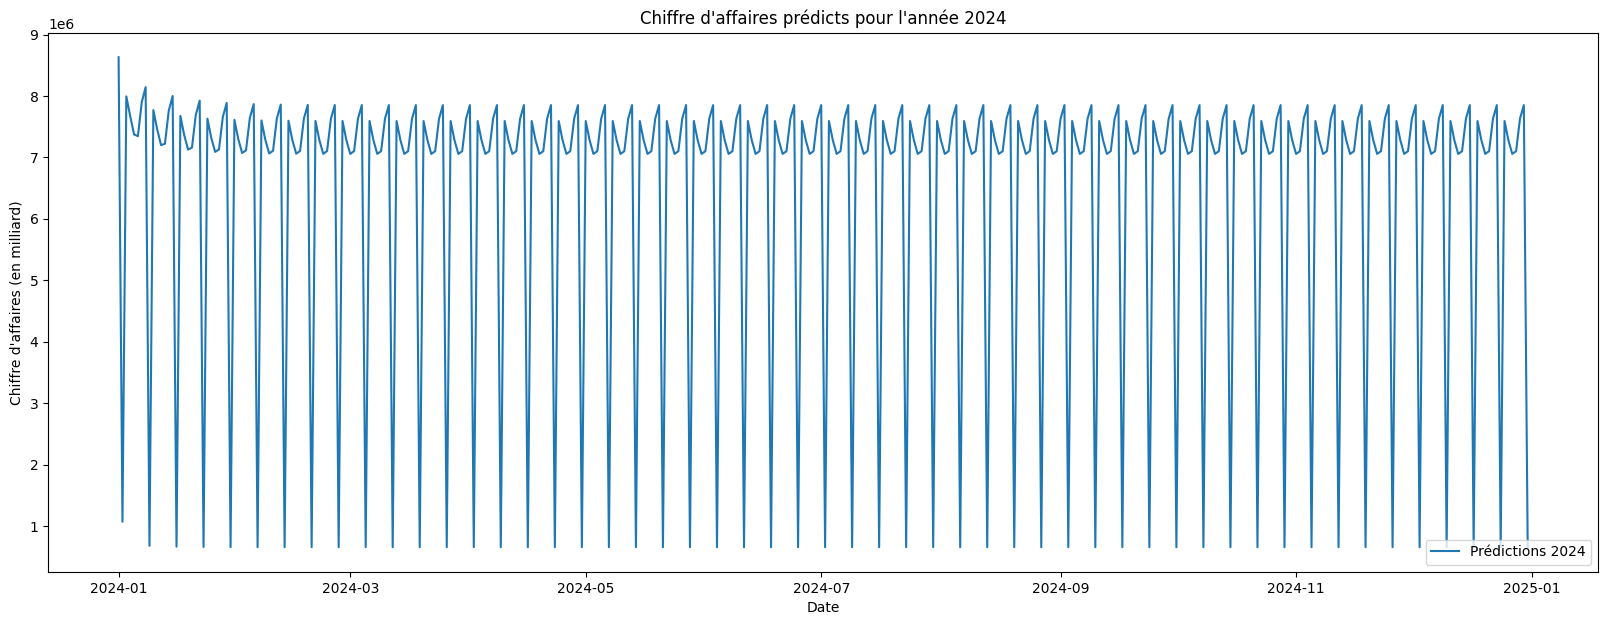

In [ ]:
# Afficher les prédictions pour l'année 2024
plt.figure(figsize=(20, 7))
plt.plot(predictions_2024_df.index, predictions_2024_df['Predictions'], label='Prédictions 2024')
plt.legend(loc="lower right")
plt.title('Chiffre d\'affaires prédicts pour l\'année 2024')
plt.xlabel('Date')
plt.ylabel('Chiffre d\'affaires (en milliard)')
plt.show()



In [ ]:
import plotly.express as px

fig = px.line(predictions_2024_df, x=predictions_2024_df.index, y=predictions_2024_df['Predictions'], title='Prédictions 2024')

fig.update_xaxes(rangeslider_visible=True)
fig. show()